INFO:purepyindi2.transports:Connected to localhost:7624


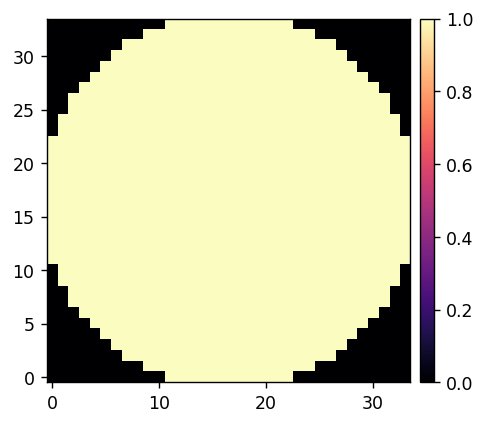

In [97]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time 
from importlib import reload
import copy
from datetime import datetime


import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle

import scoobscc


from scoobscc.math_module import xp, xcipy, ensure_np_array
from scoobscc import utils, telem, dm
from scoobscc import scc
import scoobscc.scoob_interface as scoobi

import scoobpy


from magpyx.utils import ImageStream

import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient
client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

wavelength_c = 633e-9
camsci_pxscl = 4.6e-6
camsci_pxscl_lamDc = 0.307 / 2 # divide by 2 for bin 1 

dm_mask = ensure_np_array(dm.make_mask(34))
utils.imshow([dm_mask])

## Make Experiment Directory

In [12]:
today = int(datetime.today().strftime('%Y%m%d'))
data_path = str(scoobscc.path)[:-9] + '/data_exp'

exp_path = data_path + f'/{today}_scc_dig_mono'
telem.make_dir(exp_path)

Directory '/home/derbyk/src/scoob-scc/data_exp/20250605_scc_dig_mono' created successfully.


## Initialize ImageStreams

In [13]:
reload(scoobi)
camsci_channel = 'camsci'
dm_ho_channel = 'dm00disp03'

camsci_stream = ImageStream(camsci_channel)
dm_ho_stream = ImageStream(dm_ho_channel)

## Camera Settings

In [ ]:
reload(scoobi)
xc, yc = (5656, 2619)
ncamsci = 512

scoobi.set_cam_roi(xc, yc, ncamsci, client0, cam_name=camsci_channel, bin_mode=1)
time.sleep(1)
scoobi.set_cam_exp_time(500e-6, client0, cam_name=camsci_channel)
time.sleep(1)
scoobi.set_cam_gain(120, client0, cam_name=camsci_channel)
time.sleep(1)
scoobi.set_cam_blacklevel(4, client0, cam_name=camsci_channel)

Set camsci ROI.
Set the camsci exposure time to 5.00e-04s
Set the camsci gain setting to 120.0
Set the camsci blacklevel to 4.0


## Get Dark Frame

In [15]:
reload(scoobi)
scoobi.move_block_in(client0)

INFO:utils:Got semaphore index 0.


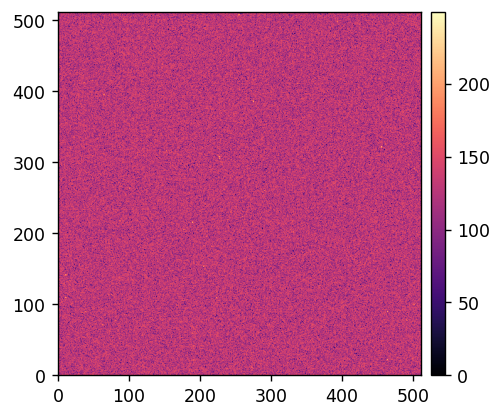

In [ ]:
reload(scoobi)
dark_frame = scoobi.snap(camsci_stream, 500)
dark_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
dark_params.update({'atten':0.0})
print(dark_params)

time.sleep(1)
scoobi.move_block_out(client0)

utils.imshow([dark_frame])

In [31]:
hdu = fits.PrimaryHDU(data=dark_frame)
hdr = hdu.header
hdr['TEXP'] = dark_params['texp']
hdr['GAIN'] = dark_params['gain']
hdr['ATTEN'] = dark_params['atten']

hdu.writeto(exp_path + '/dark_frame.fits', overwrite=True)

## Get Reference PSF


In [ ]:
scoobpy.utils.move_relative(client=client, device='stagepiezo.stagepupil_x_pos', val=100)

In [37]:
scoobpy.utils.move_relative(client=client, device='stagepiezo.stagepupil_y_pos', val=100)

In [39]:
reload(scoobi)
scoobi.set_fib_atten(30, client)

Set the fiber attenuation to 30.0


{'texp': 0.000500000023748726, 'gain': 120.0, 'atten': 30.0}


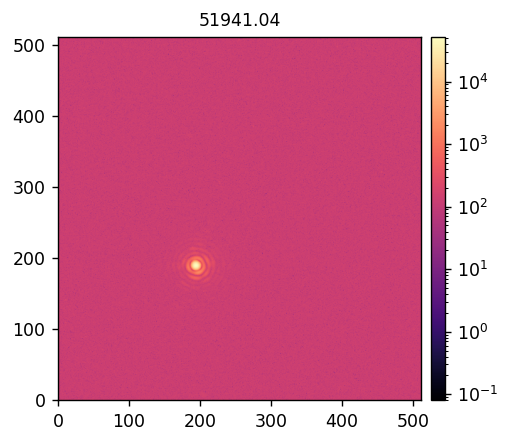

In [ ]:
reload(scoobi)
ref_psf = scoobi.snap(camsci_stream, 200)
Iref = np.max(ref_psf)
ref_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
ref_params.update({'atten':30.0})
ref_params.update({'Iref': Iref})
print(ref_params)

utils.imshow([ref_psf], titles=[f'{Iref:.2f}'], norms=[LogNorm()])

In [41]:
hdu = fits.PrimaryHDU(data=ref_psf)
hdr = hdu.header
hdr['TEXP'] = ref_params['texp']
hdr['GAIN'] = ref_params['gain']
hdr['ATTEN'] = ref_params['atten']

hdu.writeto(exp_path + '/ref_psf.fits', overwrite=True)

In [44]:
reload(scoobi)
scoobi.set_fib_atten(0, client)

Set the fiber attenuation to 0.0


In [54]:
scoobpy.utils.move_relative(client=client, device='stagepiezo.stagepupil_x_pos', val=2)

In [58]:
scoobpy.utils.move_relative(client=client, device='stagepiezo.stagepupil_y_pos', val=-2)

## Waffle For Centering

In [61]:
im_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
im_params.update({'atten':0.0})
print(im_params)

{'texp': 0.000500000023748726, 'gain': 120.0, 'atten': 0.0}


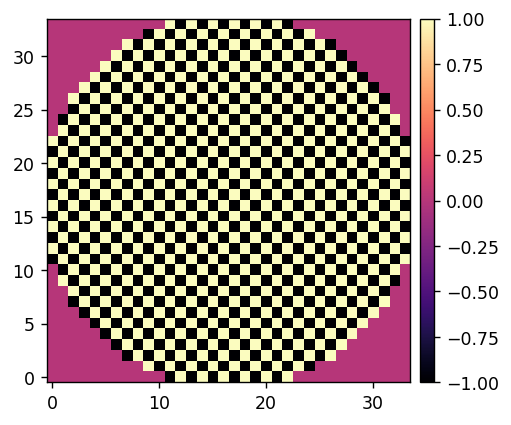

In [59]:
reload(dm)
waffle_command = ensure_np_array(dm.make_fourier_command(x_cpa=17, y_cpa=17)) * dm_mask
utils.imshow([waffle_command])

In [ ]:
reload(scoobi)
scoobi.set_dm(dm_ho_stream, 50e-9 * waffle_command)
waffle_im = scoobi.snap(camsci_stream, 100, dark_frame, im_params, ref_params)

plt.figure()
plt.imshow(waffle_im, norm='log', cmap='magma')
plt.colorbar(fraction=0.046, pad=0.04, label='Contrast')

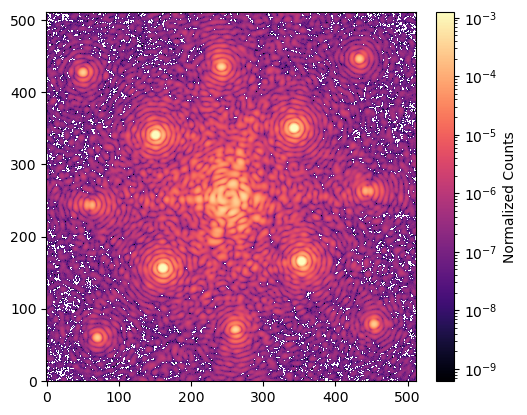

In [ ]:
scoobi.zero_dm(dm_ho_stream)

Centroids:
 [[161.27525033 155.8054845 ]
 [151.19038088 340.12510752]
 [342.88336323 349.60283843]
 [353.27035459 165.26605074]
 [161.27525033 155.8054845 ]]


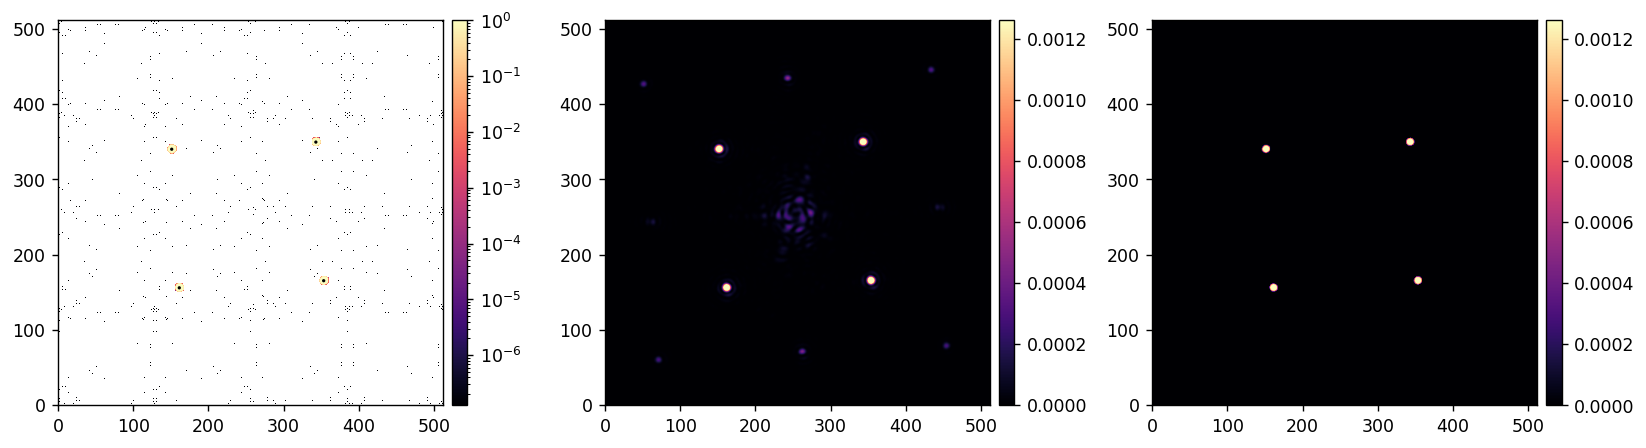

Angle:  86.9979140048417
Measured center in X:  252.14250757710437
Measured center in Y:  252.77160419784508
Required shift in X:  4.0
Required shift in Y:  3.0


In [82]:
reload(utils)

xshift, yshift, angle = utils.measure_waffle_center_and_angle(
    xp.array(waffle_im), 
    camsci_pxscl_lamDc, 
    im_thresh=5e-4, 
    r_thresh_min=16,
    r_thresh_max=25,
)

## Create Control Mask

In [ ]:
reload(utils)
iwa = 3
owa = 10
rotation = 0
control_mask = ensure_np_array( utils.create_annular_mask(
    ncamsci, 
    camsci_pxscl_lamDc,
    iwa, 
    owa, 
    edge=iwa, 
    x_shift=-xshift,
    y_shift=-yshift,
    rotation=rotation,
))

In [109]:
scoobi.set_fib_atten(10, client)

Set the fiber attenuation to 10.0


{'texp': 0.000500000023748726, 'gain': 120.0, 'atten': 10.0}


Text(0.5, 0.98, 'Control Region Contrast: 1.94e-06')

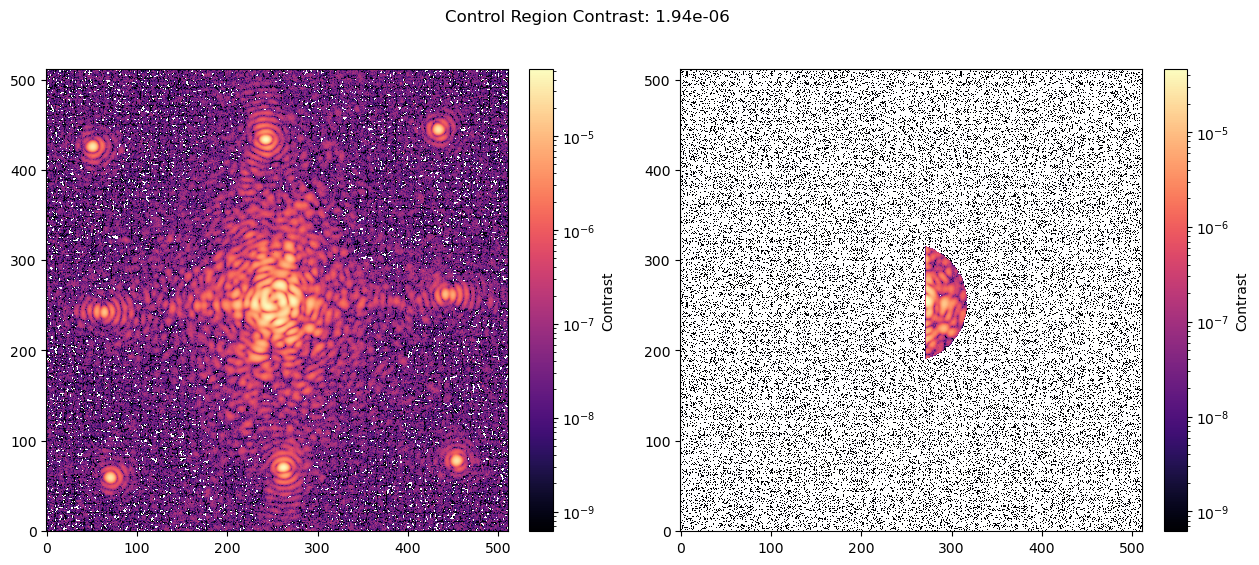

In [110]:
ref_coro_im = scoobi.snap(camsci_stream, 100, dark_frame, im_params, ref_params)
ref_coro_im[ref_coro_im < 0] = 0

im_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
im_params.update({'atten':10.0})
print(im_params)

plt.figure(figsize=(15, 6))
plt.subplot(121)
plt.imshow(ref_coro_im, norm='log', cmap='magma')
plt.colorbar(fraction=0.046, pad=0.04, label='Contrast')
plt.subplot(122)
plt.imshow(ref_coro_im * control_mask, norm='log', cmap='magma')
plt.colorbar(fraction=0.046, pad=0.04, label='Contrast')
plt.suptitle(f'Control Region Contrast: {np.mean(ref_coro_im[control_mask]):.2e}')

## Create DM Control Modes

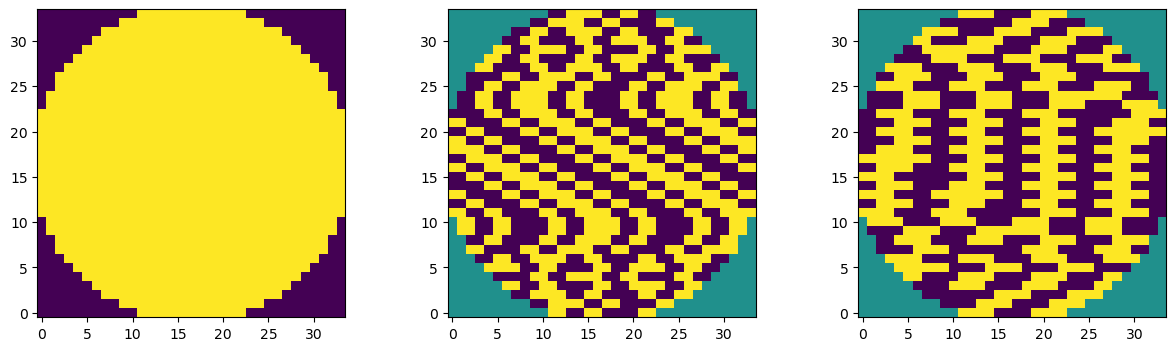

In [96]:
dm_modes = ensure_np_array(dm.create_hadamard_modes(xp.array(dm_mask))) 

plt.figure(figsize=(15, 4))
plt.subplot(131)
plt.imshow(dm_modes[0])
plt.subplot(132)
plt.imshow(dm_modes[10])
plt.subplot(133)
plt.imshow(dm_modes[100])

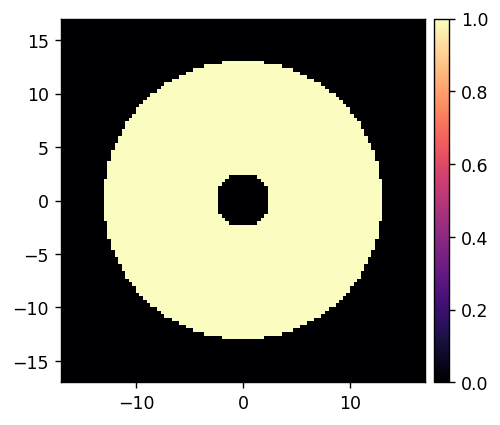

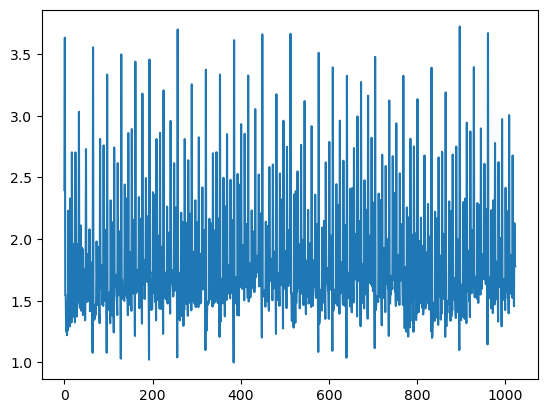

In [98]:
reload(scc)
scale_factors = scc.compute_hadamard_scale_factors(xp.array(dm_modes), scale_exp=1/5, scale_thresh=4, oversamp=3, plot=True)

## Calibrate Jacobian

In [ ]:
reload(utils)
reload(scc)

scoobi.zero_dm(dm_ho_stream)

jacobian, jacobian_full = scc.sussy_calibrate(INDIclient=client,
                                              camsci_stream=camsci_stream, 
                                              dm_stream=dm_ho_stream, 
                                              control_mask=control_mask, 
                                              calibration_amplitude=6e-9, 
                                              calibration_modes=dm_modes[:10],
                                              im_params=im_params,
                                              ref_psf_params=ref_params, 
                                              scc_reference=xp.zeros((ncamsci, ncamsci)),
                                              shift=(7, 53),
                                              diam_window=0.17,
                                              dark_frame=dark_frame,
                                              NFRAMES=10,
                                              delay=0.01,
                                              scale_factors=scale_factors, 
                                              return_full_response=True)

Sussy Calibrating Jacobian...
Pinhole is blocked, moving stagepiezo...
